## Import Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt


## Data Preprocessing

In [23]:
## Rescale pixel values (0-1) and split the data into training and validation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

## Training Generator
train_gen = train_datagen.flow_from_directory(r"C:\Users\Bhawna\Downloads\archive (1)\PetImages\train",
                    target_size=(128,128),
                    batch_size=32,
                    class_mode='binary',
                    subset='training')

## Validation Generator
val_gen = train_datagen.flow_from_directory(r"C:\Users\Bhawna\Downloads\archive (1)\PetImages\val",
                    target_size=(128,128),
                    batch_size=32,
                    class_mode='binary',
                    subset='validation')

Found 16000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Build CNN Model

In [24]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

c:\Users\Bhawna\anaconda3\envs\tensorflow\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
## Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
## Train the CNN

history = model.fit(train_gen, validation_data=val_gen, epochs=3)

c:\Users\Bhawna\anaconda3\envs\tensorflow\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
408/500 ━━━━━━━━━━━━━━━━━━━━ 56s 619ms/step - accuracy: 0.5947 - loss: 0.6991

c:\Users\Bhawna\anaconda3\envs\tensorflow\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


500/500 ━━━━━━━━━━━━━━━━━━━━ 334s 666ms/step - accuracy: 0.6058 - loss: 0.6865 - val_accuracy: 0.7050 - val_loss: 0.5502
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - accuracy: 0.7434 - loss: 0.5195 - val_accuracy: 0.7380 - val_loss: 0.5180
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 153ms/step - accuracy: 0.8090 - loss: 0.4034 - val_accuracy: 0.7730 - val_loss: 0.5133


## Evaluate performance

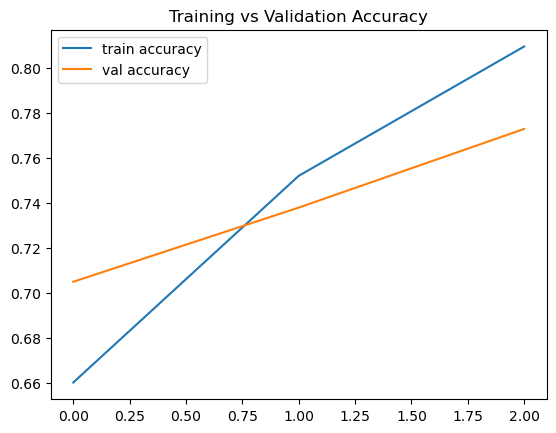

In [27]:
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

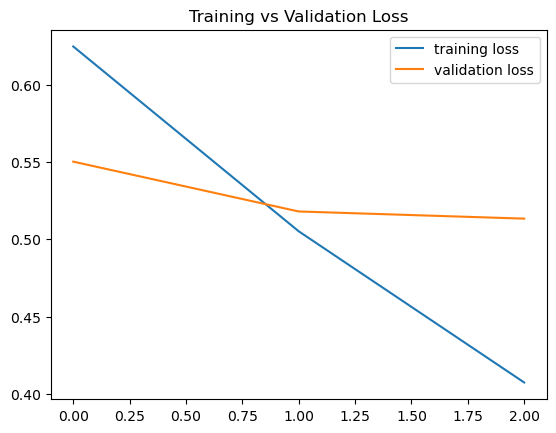

In [28]:
# Plot training vs validation loss
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()